In [203]:
import datasets
import numpy as np
from datasets import Dataset
import statsmodels.api as sm
import matplotlib.pyplot as plt
from datasets import load_dataset
from nltk.tokenize import sent_tokenize

In [3]:
ls ../data/processed/

chunks.parquet


In [43]:
paragraphs = load_dataset("parquet", data_files="../data/interim/paragraphs.parquet", streaming=False)

Generating train split: 0 examples [00:00, ? examples/s]

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

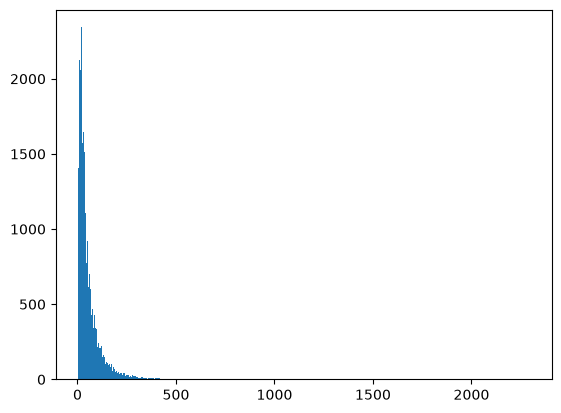

In [48]:
plt.hist(n_words_paragraphs[::1000], bins=500)
plt.show()

In [75]:
sorted_n_words_paragraphs = sorted(n_words_paragraphs)

In [76]:
sorted_n_words_paragraphs[-100:]

[np.int64(6377),
 np.int64(6386),
 np.int64(6427),
 np.int64(6447),
 np.int64(6453),
 np.int64(6462),
 np.int64(6519),
 np.int64(6572),
 np.int64(6581),
 np.int64(6775),
 np.int64(6794),
 np.int64(6852),
 np.int64(6873),
 np.int64(6876),
 np.int64(7091),
 np.int64(7136),
 np.int64(7247),
 np.int64(7286),
 np.int64(7296),
 np.int64(7296),
 np.int64(7296),
 np.int64(7297),
 np.int64(7306),
 np.int64(7306),
 np.int64(7306),
 np.int64(7306),
 np.int64(7337),
 np.int64(7394),
 np.int64(7475),
 np.int64(7475),
 np.int64(7563),
 np.int64(7647),
 np.int64(7755),
 np.int64(7797),
 np.int64(7797),
 np.int64(7797),
 np.int64(7797),
 np.int64(7833),
 np.int64(7855),
 np.int64(7874),
 np.int64(7880),
 np.int64(7905),
 np.int64(7926),
 np.int64(8030),
 np.int64(8124),
 np.int64(8258),
 np.int64(8258),
 np.int64(8258),
 np.int64(8258),
 np.int64(8594),
 np.int64(8725),
 np.int64(8776),
 np.int64(9037),
 np.int64(9037),
 np.int64(9037),
 np.int64(9037),
 np.int64(9050),
 np.int64(9079),
 np.int64(9130

In [6]:
chunks = load_dataset("parquet", data_files="../data/processed/chunks.parquet", streaming=False)

Generating train split: 0 examples [00:00, ? examples/s]

Loading dataset shards:   0%|          | 0/17 [00:00<?, ?it/s]

In [46]:
n_words_paragraphs = [n for n in paragraphs["train"]["n_words"]]
n_words_paragraphs = np.array(n_words_paragraphs)

In [110]:
splitted_paragraphs = [n for n in chunks["train"]["splitted_paragraphs"]]
splitted_paragraphs = np.array(splitted_paragraphs)

In [115]:
np.where(splitted_paragraphs == True)

(array([     505,      506,      507, ..., 15509859, 15509860, 15509861],
       shape=(21511,)),)

In [114]:
n_words = [n for n in chunks["train"]["n_words"]]
n_words = np.array(n_words)

In [29]:
n_words = np.array(n_words)

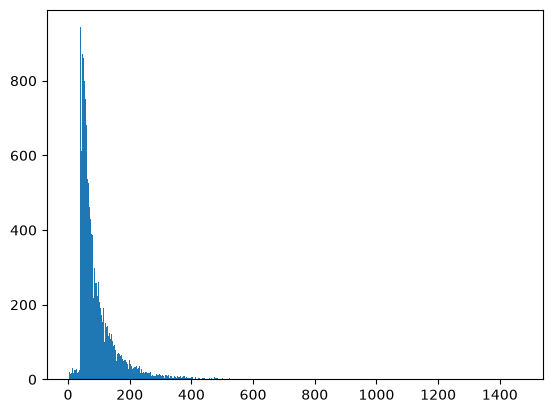

In [49]:
plt.hist(n_words[::1000], bins=500)
plt.show()

In [55]:
sorted_n_words = sorted(n_words)

In [57]:
sorted_n_words[-100:]

[np.int64(1490),
 np.int64(1490),
 np.int64(1490),
 np.int64(1490),
 np.int64(1491),
 np.int64(1492),
 np.int64(1492),
 np.int64(1492),
 np.int64(1492),
 np.int64(1493),
 np.int64(1493),
 np.int64(1493),
 np.int64(1493),
 np.int64(1494),
 np.int64(1494),
 np.int64(1494),
 np.int64(1494),
 np.int64(1494),
 np.int64(1494),
 np.int64(1495),
 np.int64(1495),
 np.int64(1496),
 np.int64(1496),
 np.int64(1496),
 np.int64(1496),
 np.int64(1496),
 np.int64(1496),
 np.int64(1496),
 np.int64(1496),
 np.int64(1496),
 np.int64(1497),
 np.int64(1497),
 np.int64(1497),
 np.int64(1498),
 np.int64(1498),
 np.int64(1498),
 np.int64(1499),
 np.int64(1499),
 np.int64(1499),
 np.int64(1499),
 np.int64(1500),
 np.int64(1500),
 np.int64(1500),
 np.int64(1511),
 np.int64(1520),
 np.int64(1537),
 np.int64(1550),
 np.int64(1550),
 np.int64(1556),
 np.int64(1594),
 np.int64(1598),
 np.int64(1599),
 np.int64(1620),
 np.int64(1675),
 np.int64(1676),
 np.int64(1698),
 np.int64(1724),
 np.int64(1779),
 np.int64(1782

Let's qq plot the two samples to compare them.

In [91]:
n = min(len(n_words), len(n_words_paragraphs))
q = np.linspace(0, 1, n)[::100]
q1 = np.quantile(sorted_n_words, q)
q2 = np.quantile(sorted_n_words_paragraphs, q)

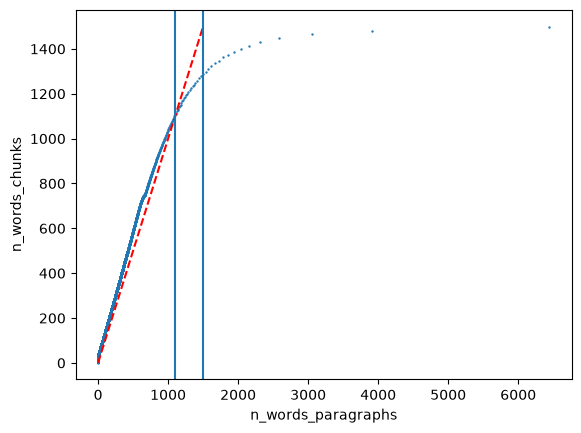

In [95]:
plt.scatter(q2, q1, s=0.5)
plt.plot([q1.min(), q1.max()], [q1.min(), q1.max()], 'r--')
plt.xlabel("n_words_paragraphs")
plt.ylabel("n_words_chunks")
plt.axvline(x=1500)
plt.axvline(x=1100)
plt.show()

In [105]:
np.where((n_words >= 1490) & (n_words <= 1500))

(array([  473060,   489195,   495823,   755817,   777842,   802384,
          992370,   993116,   993528,  1759638,  1900618,  2928059,
         3722464,  5056990,  5065569,  5079097,  5095404,  6948311,
         7156243,  7254503,  7429216,  7455899,  8508891,  9498049,
         9836440, 10066928, 10276137, 10396136, 10507985, 11316600,
        11316620, 11396678, 11727359, 12356648, 13045232, 13067415,
        13070089, 13316505, 13316686, 13316744, 13648388, 14132029,
        14287623, 14939519, 14962519]),)

In [101]:
def print_chunk_infos(chunk_id):
    """
    Takes the id of the chunk and print its content, number of words and test_id
    """
    print("N_words", chunks["train"]["n_words"][chunk_id])
    print("Text_id", chunks["train"]["text_ids"][chunk_id])
    print("Paragraph", chunks["train"]["paragraphs"][chunk_id])
    print("Splitted", chunks["train"]["splitted_paragraphs"][chunk_id])
    
    
    
    

In [102]:
np.where(n_words == 3114)

(array([5903516]),)

In [130]:
print_chunk_infos(14939519)

N_words 1497
Text_id 73425
Paragraph “It is not very easy to explain,” Saint-Loup broke in. “You read, let us say, that this or that Corps has tried ... but before we go any farther, the serial number of the Corps, its order of battle are not without their significance. If it is not the first time that the operation has been attempted, and if for the same operation we find a different Corps being brought up, it is perhaps a sign that the previous Corps have been wiped out or have suffered heavy casualties in the said operation; that they are no longer in a fit state to carry it through successfully. Next, we must ask ourselves what was this Corps which is now out of action; if it was composed of shock troops, held in reserve for big attacks, a fresh Corps of inferior quality will have little chance of succeeding where the first has failed. Furthermore, if we are not at the start of a campaign, this fresh Corps may itself be a composite formation of odds and ends withdrawn from other Co

In [131]:
np.where(n_words==1)

(array([ 3793654,  7365523, 11203310]),)

In [144]:
print_chunk_infos(7365524)

N_words 1364
Text_id 4200
Paragraph in money, and what wine she needed, for the burying him A mad merry slut she is A real and not a complimentary acknowledgment A good handsome wench I kissed, the first that I have seen A fair salute on horseback, in Rochester streets, of the lady A most conceited fellow and not over much in him A conceited man, but of no Logique in his head at all A vineyard, the first that ever I did see A pretty man, I would be content to break a commandment with him A little while since a very likely man to live as any I knew A lady spit backward upon me by a mistake A gainful trade, but yet make me great trouble A great baboon, but so much like a man in most things A play not very good, though commended much A very fine dinner A cat will be a cat still A book the Bishops will not let be printed again A woman sober, and no high-flyer, as he calls it A most tedious, unreasonable, and impertinent sermon About two o'clock, too late and too soon to go home to bed Abou

## Embedding

In [145]:
chunks = chunks.filter(lambda chunk: chunk["n_words"] >= 40)

Filter:   0%|          | 0/15538561 [00:00<?, ? examples/s]

In [146]:
chunks

DatasetDict({
    train: Dataset({
        features: ['paragraphs', 'text_ids', 'spans', 'chapters', 'n_words', 'splitted_paragraphs'],
        num_rows: 15259570
    })
})

In [147]:
n_words_chunks_filtered = [n for n in chunks["train"]["n_words"]]
n_words_chunks_filtered = np.array(n_words_chunks_filtered)

In [149]:
from sentence_transformers import SentenceTransformer

In [298]:
model = SentenceTransformer("IEITYuan/Yuan-embedding-2.0-en", device="mps:0")

In [168]:
def encode_chunk(chunk, batch_size= 64, convert_to_numpy=True, normalize_embeddings=True):
    """
    Wrapper to the embedding function, for using with .map.
    """
    print(chunk)
    return {"embeddings":model.encode(chunk, batch_size= 64,convert_to_numpy=True, normalize_embeddings=True)}
    

In [169]:
chunks = chunks.map(lambda chunk, batch_size, convert_to_numpy, 
                    normalize_embeddings: encode_chunk(chunk["paragraphs"], batch_size, convert_to_numpy, normalize_embeddings), 
                    fn_kwargs={"batch_size": 1, "convert_to_numpy":True, "normalize_embeddings":True},
                    batch_size=64, batched=True)

Map:   0%|          | 0/15259570 [00:00<?, ? examples/s]

['Having, by a train of fortunate circumstances, accomplished a voyage, of which the history of mankind affords no example; having, moreover, exerted every faculty of body and mind, to make my adventures useful to my countrymen, and even to mankind, by imparting to them the acquisition of secrets in physics and morals, of which they had not formed the faintest conception,--I flattered myself that both in the character of traveller and public benefactor, I had earned for myself an immortal name. But how these fond, these justifiable hopes have been answered, the following narrative will show.', 'On my return to this my native State, as soon as it was noised abroad that I had met with extraordinary adventures, and made a most wonderful voyage, crowds of people pressed eagerly to see me. I at first met their inquiries with a cautious silence, which, however, but sharpened their curiosity. At length I was visited by a near relation, with whom I felt less disposed to reserve. With friendly 


KeyboardInterrupt



KeyboardInterrupt: 

In [166]:
import torch
print(torch.cuda.is_available())
print(model.device)

False
mps:0


In [172]:
chunks["train"]["paragraphs"][0]

'Having, by a train of fortunate circumstances, accomplished a voyage, of which the history of mankind affords no example; having, moreover, exerted every faculty of body and mind, to make my adventures useful to my countrymen, and even to mankind, by imparting to them the acquisition of secrets in physics and morals, of which they had not formed the faintest conception,--I flattered myself that both in the character of traveller and public benefactor, I had earned for myself an immortal name. But how these fond, these justifiable hopes have been answered, the following narrative will show.'

In [195]:
model = model.eval()

In [209]:
chunks["train"]["paragraphs"]

Column(['Having, by a train of fortunate circumstances, accomplished a voyage, of which the history of mankind affords no example; having, moreover, exerted every faculty of body and mind, to make my adventures useful to my countrymen, and even to mankind, by imparting to them the acquisition of secrets in physics and morals, of which they had not formed the faintest conception,--I flattered myself that both in the character of traveller and public benefactor, I had earned for myself an immortal name. But how these fond, these justifiable hopes have been answered, the following narrative will show.', 'On my return to this my native State, as soon as it was noised abroad that I had met with extraordinary adventures, and made a most wonderful voyage, crowds of people pressed eagerly to see me. I at first met their inquiries with a cautious silence, which, however, but sharpened their curiosity. At length I was visited by a near relation, with whom I felt less disposed to reserve. With fr

In [208]:
test_ds = Dataset.from_dict(chunks["train"]["paragraphs"][0:1024])

AttributeError: 'list' object has no attribute 'items'

In [210]:
texts = chunks["train"].select(range(1024))["paragraphs"]

In [215]:
texts[1024]

IndexError: Invalid key: 1024 is out of bounds for size 1024

In [300]:
%%time
model = model.eval()
with torch.no_grad():
    model.max_seq_length = 2048
    sorted_chunks = sorted(chunks["train"]["paragraphs"][0:10], key=len)
    embeddings = model.encode(sorted_chunks, device="mps:0",  batch_size= 128,convert_to_numpy=True, normalize_embeddings=True, num_proc = 8)

CPU times: user 307 ms, sys: 24.6 s, total: 24.9 s
Wall time: 2min 24s


In [294]:
15000000/(2*4096)*7/60

213.623046875

In [228]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(
    "BAAI/bge-small-en-v1.5",
    use_fast=True
)

In [238]:
tt = Dataset.from_dict({"text":chunks["train"]["paragraphs"][0:1000000]})

In [243]:
%time
tokenized_ds = chunks.map(lambda t:tokenizer(t['paragraphs']), batched=True)

CPU times: user 6 μs, sys: 2 μs, total: 8 μs
Wall time: 16.7 μs


Map:   0%|          | 0/15259570 [00:00<?, ? examples/s]

In [249]:
help(model)

Help on SentenceTransformer in module sentence_transformers.SentenceTransformer object:

class SentenceTransformer(torch.nn.modules.container.Sequential, sentence_transformers.fit_mixin.FitMixin, sentence_transformers.peft_mixin.PeftAdapterMixin)
 |  SentenceTransformer(model_name_or_path: 'str | None' = None, modules: 'Iterable[nn.Module] | None' = None, device: 'str | None' = None, prompts: 'dict[str, str] | None' = None, default_prompt_name: 'str | None' = None, similarity_fn_name: 'str | SimilarityFunction | None' = None, cache_folder: 'str | None' = None, trust_remote_code: 'bool' = False, revision: 'str | None' = None, local_files_only: 'bool' = False, token: 'bool | str | None' = None, use_auth_token: 'bool | str | None' = None, truncate_dim: 'int | None' = None, model_kwargs: 'dict[str, Any] | None' = None, tokenizer_kwargs: 'dict[str, Any] | None' = None, config_kwargs: 'dict[str, Any] | None' = None, model_card_data: 'SentenceTransformerModelCardData | None' = None, backend: 

In [278]:
%%time
with torch.no_grad():
    outputs = model(
        d
    )


CPU times: user 419 μs, sys: 254 μs, total: 673 μs
Wall time: 680 μs


AttributeError: 'Column' object has no attribute 'size'

In [277]:
d = {'input_ids':tokenized_ds["train"]['input_ids'], 
 'token_type_ids':tokenized_ds["train"]['token_type_ids'], 
'attention_mask':tokenized_ds["train"]['attention_mask']}

In [276]:
tokenized_ds["train"]

Dataset({
    features: ['paragraphs', 'text_ids', 'spans', 'chapters', 'n_words', 'splitted_paragraphs', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 15259570
})

In [275]:
help(tokenized_ds)

Help on DatasetDict in module datasets.dataset_dict object:

class DatasetDict(builtins.dict)
 |  A dictionary (dict of str: datasets.Dataset) with dataset transforms methods (map, filter, etc.)
 |  
 |  Method resolution order:
 |      DatasetDict
 |      builtins.dict
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __enter__(self)
 |  
 |  __exit__(self, exc_type, exc_val, exc_tb)
 |  
 |  __getitem__(self, k) -> datasets.arrow_dataset.Dataset
 |      x.__getitem__(y) <==> x[y]
 |  
 |  __repr__(self)
 |      Return repr(self).
 |  
 |  align_labels_with_mapping(self, label2id: dict, label_column: str) -> 'DatasetDict'
 |      Align the dataset's label ID and label name mapping to match an input `label2id` mapping.
 |      This is useful when you want to ensure that a model's predicted labels are aligned with the dataset.
 |      The alignment in done using the lowercase label names.
 |      
 |      Args:
 |          label2id (`dict`):
 |              The label name 

In [177]:
print(torch.cuda.is_available())
print(next(model.parameters()).device)

False
mps:0


In [178]:
torch.backends.mps.is_available()

True

In [179]:
print(next(model.parameters()).device)

mps:0


In [229]:
chunks["train"]["paragraphs"][0:(2*4096)]

['Having, by a train of fortunate circumstances, accomplished a voyage, of which the history of mankind affords no example; having, moreover, exerted every faculty of body and mind, to make my adventures useful to my countrymen, and even to mankind, by imparting to them the acquisition of secrets in physics and morals, of which they had not formed the faintest conception,--I flattered myself that both in the character of traveller and public benefactor, I had earned for myself an immortal name. But how these fond, these justifiable hopes have been answered, the following narrative will show.',
 'On my return to this my native State, as soon as it was noised abroad that I had met with extraordinary adventures, and made a most wonderful voyage, crowds of people pressed eagerly to see me. I at first met their inquiries with a cautious silence, which, however, but sharpened their curiosity. At length I was visited by a near relation, with whom I felt less disposed to reserve. With friendly

In [192]:
model

SentenceTransformer(
  (0): Transformer({'max_seq_length': 32768, 'do_lower_case': False}) with Transformer model: Qwen3Model 
  (1): Pooling({'word_embedding_dimension': 1024, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': False, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': True, 'include_prompt': True})
  (2): Normalize()
)

In [197]:
chunks

DatasetDict({
    train: Dataset({
        features: ['paragraphs', 'text_ids', 'spans', 'chapters', 'n_words', 'splitted_paragraphs'],
        num_rows: 15259570
    })
})

In [ ]:
model.max_seq_length = 128

In [297]:
np.percentile(n_words_chunks_filtered, 99.9)

np.float64(807.0)